<a href="https://colab.research.google.com/github/frayyan-rgb/amazon-employee-feedback-analysis/blob/main/03_keyword_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [50]:
import pandas as pd

In [51]:
df = pd.read_csv("glassdoor_cleaned_text.csv")

In [52]:
df.head()

,review_id,rating_date,count_helpful,employee_length,employee_status,employee_type,flags_business_outlook,flags_ceo_approval,flags_recommend_frend,rating_culture_values,...,advice_to_management,review_pros,review_cons,rating_compensation_benefits,rating_senior_leadership,rating_career_opportunities,summary_cleaned,advice_to_management_cleaned,review_pros_cleaned,review_cons_cleaned
0,1,2025-06-03,0.0,0.0,REGULAR,Current employee,NaN,NaN,NaN,0.0,...,don’t micro manage,not interactive \ncan leave or take off whenev...,inhumane \ndraining physically &amp; mentally,0.0,0.0,0.0,amazon,don’t micro manage,interactive leave take whenever long time easy...,inhumane draining physically amp mentally
1,2,2025-05-29,0.0,1.0,CONTRACT,"Current employee, less than 1 year",POSITIVE,APPROVE,POSITIVE,5.0,...,remove all attitude manager from warehouse,good and easy work enviorment,"sticks rules and completing targets any how, o...",5.0,3.0,5.0,good,remove attitude manager warehouse,good easy work enviorment,sticks rules completing targets otherwise get ...
2,3,2025-05-28,0.0,1.0,REGULAR,"Current employee, less than 1 year",POSITIVE,APPROVE,POSITIVE,5.0,...,NaN,"help to grow , good pay ,","limited opportunities for advancement,no clear...",5.0,5.0,5.0,good experience,NaN,help grow good pay,limited opportunities advancementno clear path...
3,4,2025-05-26,0.0,2.0,PART_TIME,Current employees,POSITIVE,APPROVE,POSITIVE,2.0,...,NaN,plenty of work\nmeet new people,tough on the body\nlabor intensive,2.0,2.0,3.0,dhdh,NaN,plenty work meet new people,tough body labor intensive
4,5,2025-05-23,0.0,0.0,REGULAR,Current employee,NaN,NaN,NaN,0.0,...,NaN,good holiday pay \nadditional benefits for per...,not hiring permanent employees directly,0.0,0.0,0.0,good pay rate,NaN,good holiday pay additional benefits permanent...,hiring permanent employees directly


In [53]:
df['cleaned_text'] = (
    df['summary_cleaned'].fillna('') + ' ' +
    df['advice_to_management_cleaned'].fillna('') + ' ' +
    df['review_pros_cleaned'].fillna('') + ' ' +
    df['review_cons_cleaned'].fillna('')
)

In [54]:
from collections import Counter

# Join all cleaned reviews into one big string, then split into words
all_words = ' '.join(df['cleaned_text']).split()

# Count frequency of each word
word_counts = Counter(all_words)
print(word_counts.most_common(6))

[('work', 108), ('good', 87), ('pay', 64), ('benefits', 46), ('job', 40), ('get', 39)]


In [55]:
df.head()

,review_id,rating_date,count_helpful,employee_length,employee_status,employee_type,flags_business_outlook,flags_ceo_approval,flags_recommend_frend,rating_culture_values,...,review_pros,review_cons,rating_compensation_benefits,rating_senior_leadership,rating_career_opportunities,summary_cleaned,advice_to_management_cleaned,review_pros_cleaned,review_cons_cleaned,cleaned_text
0,1,2025-06-03,0.0,0.0,REGULAR,Current employee,NaN,NaN,NaN,0.0,...,not interactive \ncan leave or take off whenev...,inhumane \ndraining physically &amp; mentally,0.0,0.0,0.0,amazon,don’t micro manage,interactive leave take whenever long time easy...,inhumane draining physically amp mentally,amazon don’t micro manage interactive leave ta...
1,2,2025-05-29,0.0,1.0,CONTRACT,"Current employee, less than 1 year",POSITIVE,APPROVE,POSITIVE,5.0,...,good and easy work enviorment,"sticks rules and completing targets any how, o...",5.0,3.0,5.0,good,remove attitude manager warehouse,good easy work enviorment,sticks rules completing targets otherwise get ...,good remove attitude manager warehouse good ea...
2,3,2025-05-28,0.0,1.0,REGULAR,"Current employee, less than 1 year",POSITIVE,APPROVE,POSITIVE,5.0,...,"help to grow , good pay ,","limited opportunities for advancement,no clear...",5.0,5.0,5.0,good experience,NaN,help grow good pay,limited opportunities advancementno clear path...,good experience help grow good pay limited op...
3,4,2025-05-26,0.0,2.0,PART_TIME,Current employees,POSITIVE,APPROVE,POSITIVE,2.0,...,plenty of work\nmeet new people,tough on the body\nlabor intensive,2.0,2.0,3.0,dhdh,NaN,plenty work meet new people,tough body labor intensive,dhdh plenty work meet new people tough body l...
4,5,2025-05-23,0.0,0.0,REGULAR,Current employee,NaN,NaN,NaN,0.0,...,good holiday pay \nadditional benefits for per...,not hiring permanent employees directly,0.0,0.0,0.0,good pay rate,NaN,good holiday pay additional benefits permanent...,hiring permanent employees directly,good pay rate good holiday pay additional ben...


In [56]:
import pandas as pd

word_df = pd.DataFrame(word_counts.items(), columns=['word', 'count']).sort_values(by='count', ascending=False)

In [57]:
import re

all_words_clean = [w for w in all_words if re.fullmatch(r"[a-z]+", w)]
stop_keywords = ['team', 'company', 'job', 'work', 'amazon', 'amp', 'dont']
filtered_words = [w for w in all_words_clean if w not in stop_keywords]
filtered_counts = Counter(filtered_words)
print(filtered_counts.most_common(10))

[('good', 87), ('pay', 64), ('benefits', 46), ('get', 39), ('hours', 31), ('people', 30), ('great', 29), ('time', 25), ('place', 21), ('long', 20)]


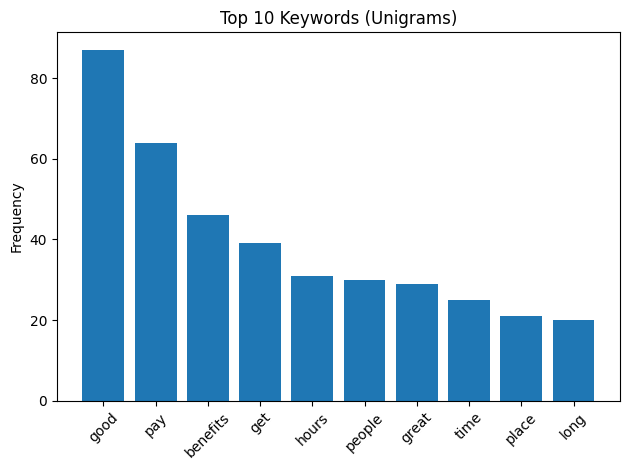

In [58]:
import matplotlib.pyplot as plt

most_common = filtered_counts.most_common(10)
words, counts = zip(*most_common)

plt.bar(words, counts)
plt.title("Top 10 Keywords (Unigrams)")
plt.xticks(rotation=45)
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [59]:
from nltk.util import ngrams

bigrams = list(ngrams(all_words, 2))
trigrams = list(ngrams(all_words, 3))

bigram_counts = Counter(bigrams)
trigram_counts = Counter(trigrams)


In [60]:
print(bigram_counts.most_common(3))
# [(('supportive', 'team'), 2), (('team', 'great'), 1), (('great', 'training'), 1)]

[(('good', 'pay'), 17), (('good', 'benefits'), 11), (('place', 'work'), 10)]


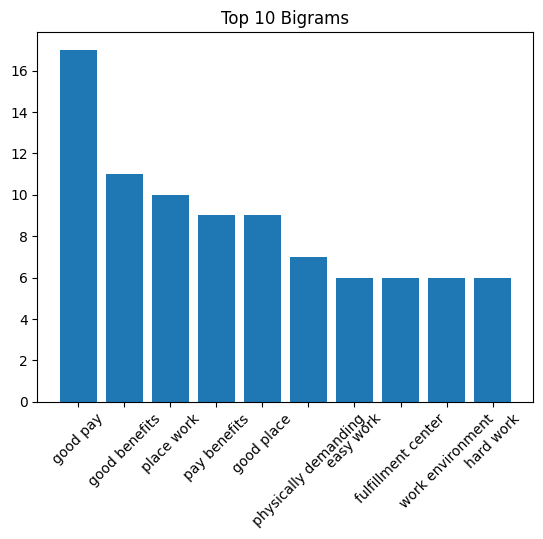

In [61]:
# For bigrams
common_bigrams = bigram_counts.most_common(10)
bg_labels = [' '.join(bg) for bg, count in common_bigrams]
bg_counts = [count for bg, count in common_bigrams]

plt.bar(bg_labels, bg_counts)
plt.title("Top 10 Bigrams")
plt.xticks(rotation=45)
plt.show()


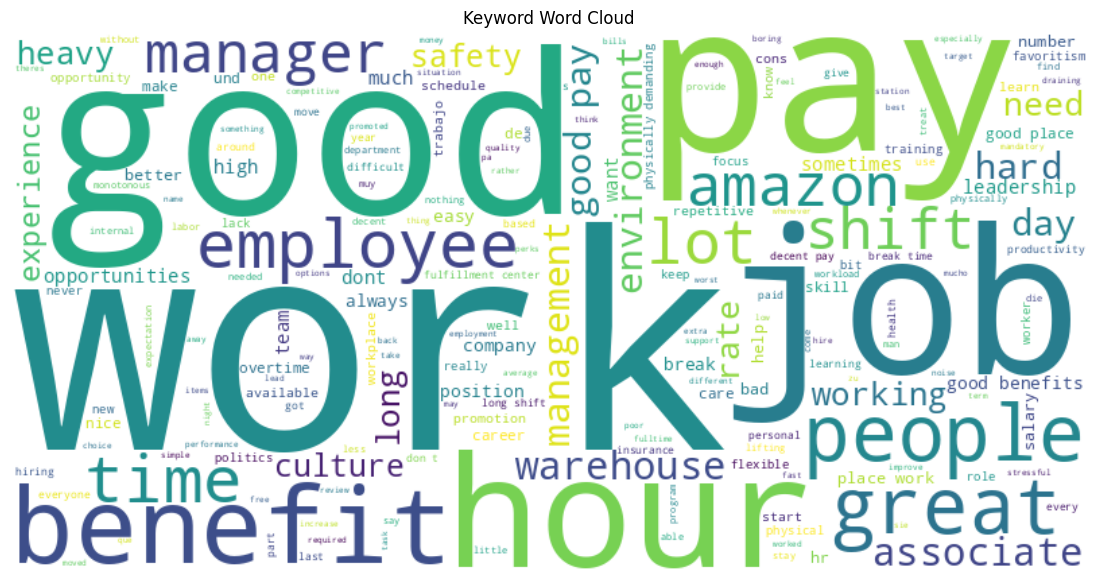

In [62]:
from wordcloud import WordCloud

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(all_words))

plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Keyword Word Cloud")
plt.show()

In [63]:
from collections import Counter
from nltk.util import ngrams
from wordcloud import WordCloud
import matplotlib.pyplot as plt

df2 = pd.read_csv("youtube_cleaned_text.csv")
df2['cleaned_text'] = df2['transcript_cleaned'].fillna('')
df2 = df2[df2['cleaned_text'].str.strip() != '']

# Tokenize and count
yt_words = ' '.join(df2['cleaned_text']).split()

# Filter noise (see note below)
stop_keywords = ['like', 'yeah', 'um', 'uh', 'know', 'really', 'going', 'get', 'got', 'one', 'amazon', 'work', 'job']
yt_words = [w for w in yt_words if w not in stop_keywords]

yt_counts = Counter(yt_words)
print(yt_counts.most_common(10))

[('—', 23), ('im', 13), ('shift', 10), ('time', 6), ('working', 6), ('night', 6), ('day', 6), ('hours', 6), ('much', 5), ('dont', 5)]


In [64]:
import re

# Drop anything that isn't a plain word
yt_words = [w for w in yt_words if re.fullmatch(r"[a-z]+", w)]

# Contraction fragments + vague fillers
extra_stop = ['im','dont','ive','cant','didnt','thats','youre','its','theyre','doesnt','wasnt',
              'much','really','like','yeah','know','get','got','one','also','would']
yt_words = [w for w in yt_words if w not in extra_stop]

yt_counts = Counter(yt_words)
print(yt_counts.most_common(15))

[('shift', 10), ('time', 6), ('working', 6), ('night', 6), ('day', 6), ('hours', 6), ('tired', 4), ('people', 4), ('enjoy', 4), ('super', 4), ('think', 4), ('worth', 4), ('sleep', 3), ('feel', 3), ('lot', 3)]


In [65]:
yt_words = ' '.join(df2['cleaned_text']).split()

In [66]:
df2['cleaned_text'] = df2['transcript_cleaned'].fillna('')
df2 = df2[df2['cleaned_text'].str.strip() != '']

In [67]:
# keep only plain words (removes em dashes, curly quotes, etc.)
yt_words = [w for w in yt_words if re.fullmatch(r"[a-z]+", w)]

extra_stop = ['im', 'amazon','dont','ive','cant','didnt','thats','youre','its','theyre','doesnt','wasnt',
              'much','really','like','yeah','know','get','got','one','also','would',
              'think','feel','lot','super','amp']
yt_words = [w for w in yt_words if w not in extra_stop]

In [68]:
yt_counts = Counter(yt_words)
print(yt_counts.most_common(15))
print(len(yt_words), len(df2))

[('work', 12), ('shift', 10), ('time', 6), ('working', 6), ('night', 6), ('day', 6), ('hours', 6), ('tired', 4), ('people', 4), ('enjoy', 4), ('worth', 4), ('sleep', 3), ('job', 3), ('go', 3), ('repetitive', 3)]
378 9


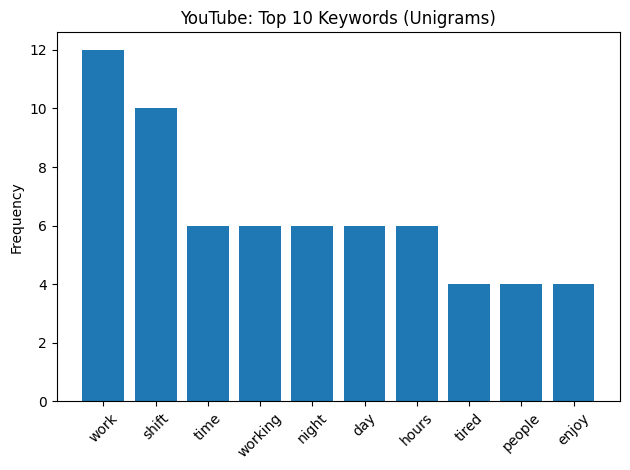

In [69]:
words, counts = zip(*yt_counts.most_common(10))
plt.bar(words, counts)
plt.title("YouTube: Top 10 Keywords (Unigrams)")
plt.xticks(rotation=45)
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig('youtube_unigrams.png', bbox_inches='tight')
plt.show()

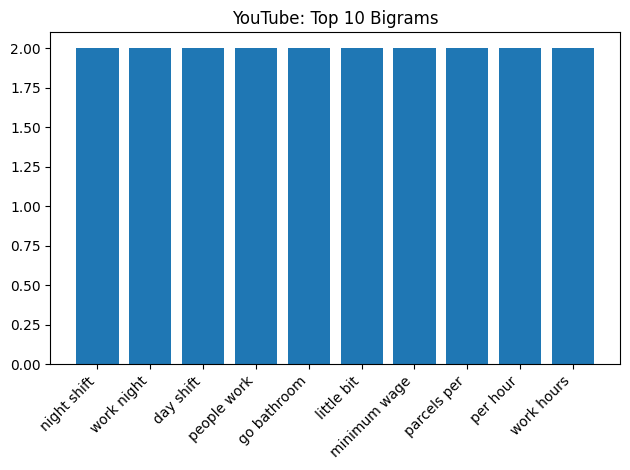

In [70]:
yt_bigrams = Counter(ngrams(yt_words, 2))
common = yt_bigrams.most_common(10)
plt.bar([' '.join(b) for b, c in common], [c for b, c in common])
plt.title("YouTube: Top 10 Bigrams")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('youtube_bigrams.png', bbox_inches='tight')
plt.show()

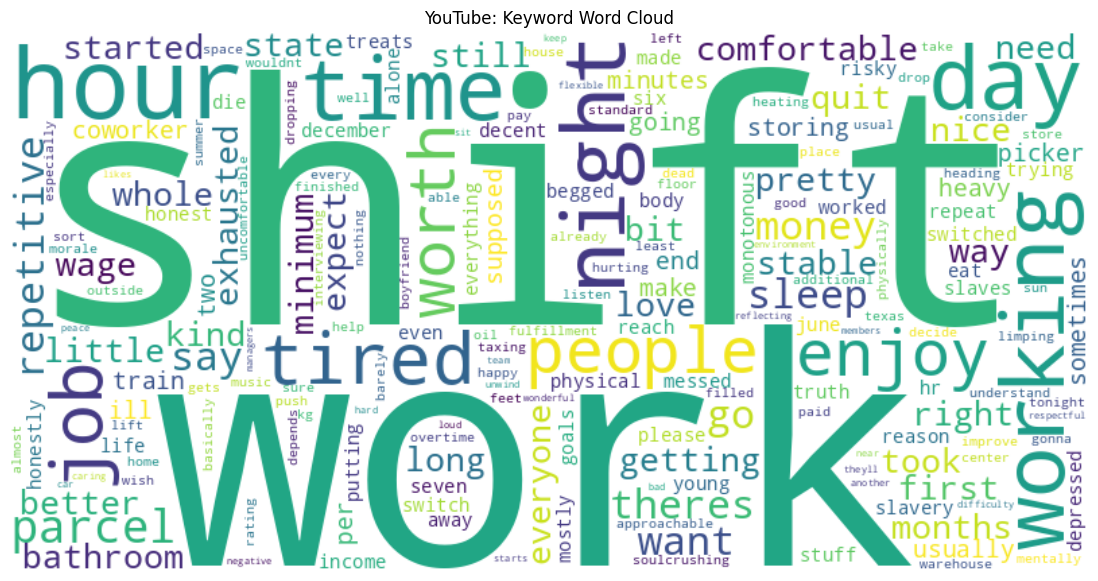

In [71]:
wc = WordCloud(width=800, height=400, background_color='white').generate(' '.join(yt_words))
plt.figure(figsize=(15, 7))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title("YouTube: Keyword Word Cloud")
plt.savefig('youtube_wordcloud.png', bbox_inches='tight')
plt.show()